<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/Projects_2/blob/Shreya_Merin/Ridewiseweek3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [4]:
from google.colab import files
uploaded = files.upload()

day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

print(day.shape, hour.shape)
day.head(), hour.head()


Saving day.csv to day (2).csv
Saving hour.csv to hour.csv
(731, 16) (17379, 17)


(   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
 0        1  2011-01-01       1   0     1        0        6           0   
 1        2  2011-01-02       1   0     1        0        0           0   
 2        3  2011-01-03       1   0     1        0        1           1   
 3        4  2011-01-04       1   0     1        0        2           1   
 4        5  2011-01-05       1   0     1        0        3           1   
 
    weathersit      temp     atemp       hum  windspeed  casual  registered  \
 0           2  0.344167  0.363625  0.805833   0.160446     331         654   
 1           2  0.363478  0.353739  0.696087   0.248539     131         670   
 2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
 3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
 4           1  0.226957  0.229270  0.436957   0.186900      82        1518   
 
     cnt  
 0   985  
 1   801  
 2  1349  
 3  1562  
 4  1600  ,
    i

In [5]:

print("DAY INFO:")
print(day.info())
print("\nHOUR INFO:")
print(hour.info())

print("\nMissing Values (Day):")
print(day.isnull().sum())

print("\nMissing Values (Hour):")
print(hour.isnull().sum())

print("\nDay Describe:")
print(day.describe())

print("\nHour Describe:")
print(hour.describe())


DAY INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

HOUR INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0

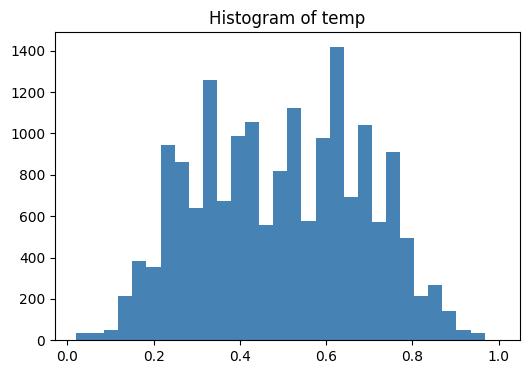

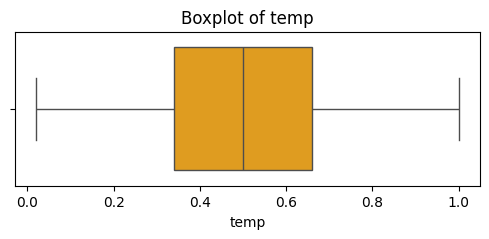

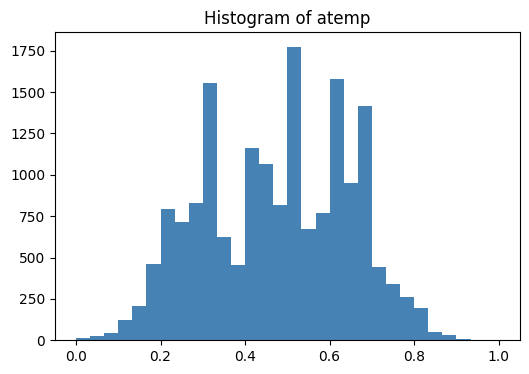

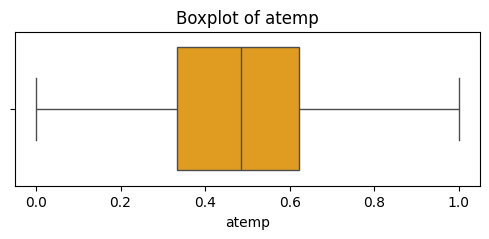

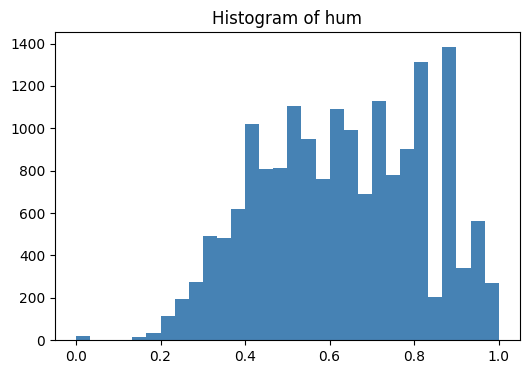

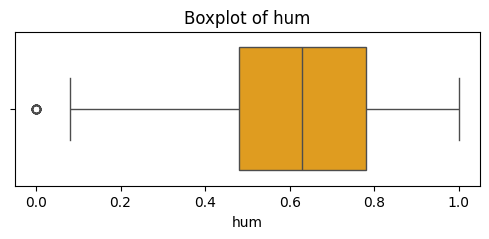

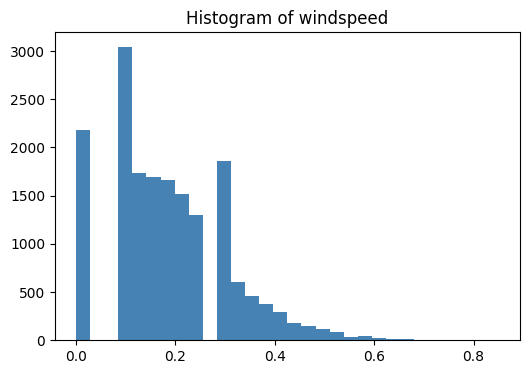

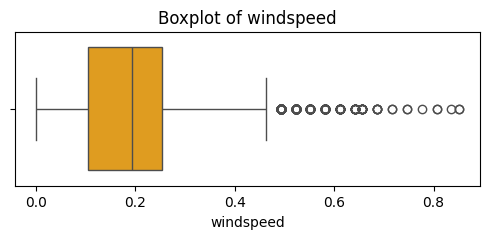

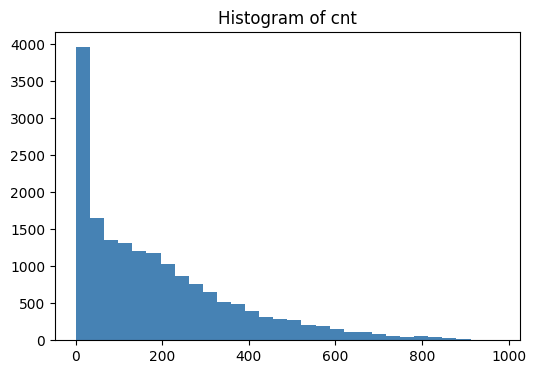

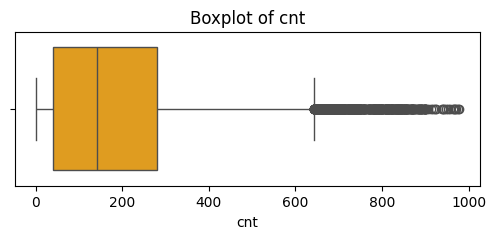

In [6]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(hour[col], bins=30, color='steelblue')
    plt.title(f"Histogram of {col}")
    plt.show()

    plt.figure(figsize=(6,2))
    sns.boxplot(x=hour[col], color='orange')
    plt.title(f"Boxplot of {col}")
    plt.show()


In [7]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df_clean = hour.copy()

for col in numeric_cols:
    df_clean = remove_outliers_iqr(df_clean, col)

print("Original shape:", hour.shape)
print("After outlier removal:", df_clean.shape)


Original shape: (17379, 17)
After outlier removal: (16535, 17)


In [8]:

columns_to_drop = ['instant', 'dteday', 'yr', 'casual', 'registered']
df_clean.drop(columns=columns_to_drop, inplace=True, errors='ignore')

df_clean.head()


,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [9]:
df_clean['is_weekend'] = df_clean['weekday'].isin([0,6]).astype(int)

def is_peak(hour):
    return 1 if hour in [7,8,9,17,18,19] else 0

df_clean['is_peak'] = df_clean['hr'].apply(is_peak)

df_clean.head()


,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,is_weekend,is_peak
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1,0
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1,0
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1,0
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1,0
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,0


In [10]:

X = df_clean.drop('cnt', axis=1)
y = df_clean['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((13228, 13), (3307, 13))

In [11]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)


Linear Regression Results:
MAE : 82.13594917987615
RMSE: 107.84423477460419
R²  : 0.5089604080590595


In [12]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)



Random Forest Results:
MAE : 38.76944444504442
RMSE: 58.35507867790392
R²  : 0.8562261304086398
